# Imports/Settings

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
# 1. Стандартная библиотека
import os
import sys
import warnings
from pathlib import Path
import joblib

# --- ДИНАМИЧЕСКИЙ РАСЧЕТ АБСОЛЮТНЫХ ПУТЕЙ ---
notebook_dir = Path(os.getcwd()).resolve()
if notebook_dir.name == "notebooks":
    PROJECT_ROOT = notebook_dir.parent
else:
    PROJECT_ROOT = notebook_dir

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 2. Сторонние библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

# 3. Локальные модули
from src.core.data import DevDuckDBDataSource
from src.core.models import get_model
from src.core.splitting import split_data
from src.core.utils import load_hydra_config
from src.eda.shap_explainer import ShapExplainer

# --- РАБОТА С ПРЕДУПРЕЖДЕНИЯМИ ---
warnings.filterwarnings('ignore', category=UserWarning, module='shap')
warnings.filterwarnings('ignore', category=FutureWarning)

# --- ИНИЦИАЛИЗАЦИЯ HYDRA ---
load_hydra_config.cache_clear()
cfg = load_hydra_config()

run_name = Path(cfg.run_name)
reports_dir = Path(cfg.paths.reports_dir / run_name)
reports_dir.mkdir(parents=True, exist_ok=True)

print(f"Проект: {cfg.project_name} | Режим: Error Analysis")

# --- НАСТРОЙКИ ВИЗУАЛИЗАЦИИ ---
try:
    p_cfg = cfg.logging.plots
    plt.style.use(p_cfg.style)
    plt.rcParams.update({
        'figure.figsize': p_cfg.fig_size,
        'figure.dpi': p_cfg.dpi,
        'font.size': p_cfg.font_size,
        'axes.grid': p_cfg.grid,
        'axes.spines.top': p_cfg.spines_top,
        'axes.spines.right': p_cfg.spines_right
    })
    PLOT_ALPHA = p_cfg.alpha
except AttributeError:
    PLOT_ALPHA = 0.5
    print("Используются дефолтные стили Matplotlib.")

Проект: credit-risk-model | Режим: Error Analysis


# Data Loading

In [4]:
loader = DevDuckDBDataSource(cfg, PROJECT_ROOT)
df = loader.load()
_, val_df, _ = split_data(cfg=cfg, df=df)

target = cfg.data.tabular.target_col
X_val, y_val = val_df.drop(columns=[target]), val_df[target]

# Пути к сохраненным объектам
models_dir = PROJECT_ROOT / cfg.paths.models_dir
model_version = cfg.model.model_version
preprocessor_version = cfg.data.tabular.preprocessing_version
model_name = cfg.model.name

In [5]:
print("Загрузка препроцессора и пайплайна модели...")
prep = joblib.load(models_dir / f"preprocessing_v{preprocessor_version}.pkl")

model_wrapper = get_model(cfg, project_root=PROJECT_ROOT)
model_wrapper.load(str(models_dir / f"{model_name}_v{model_version}.cbm"))

# Трансформируем признаки (SHAP требует матрицу, которую видела сама модель на входе в fit)
X_val_clean = prep.transform(X_val)

Загрузка препроцессора и пайплайна модели...


In [6]:
# Превращаем в DataFrame с правильными именами колонок после препроцессинга
if hasattr(prep, 'get_feature_names_out'):
    feature_names = prep.get_feature_names_out()
    X_val_clean_df = pd.DataFrame(X_val_clean, columns=feature_names)
else:
    X_val_clean_df = pd.DataFrame(X_val_clean, columns=X_val.columns)

print(f"Данные готовы к расчету SHAP-значений. Формат: {X_val_clean_df.shape}")

Данные готовы к расчету SHAP-значений. Формат: (39276, 55)


# SHAP Explainer init

In [8]:
shap_explainer = ShapExplainer(X_val_clean_df=X_val_clean_df, y_val=y_val, model_wrapper=model_wrapper, config=cfg, project_root=PROJECT_ROOT)

Инициализация TreeExplainer...
Расчет SHAP-значений для валидационной выборки...
Расчет успешно завершен!


# Global interpretation

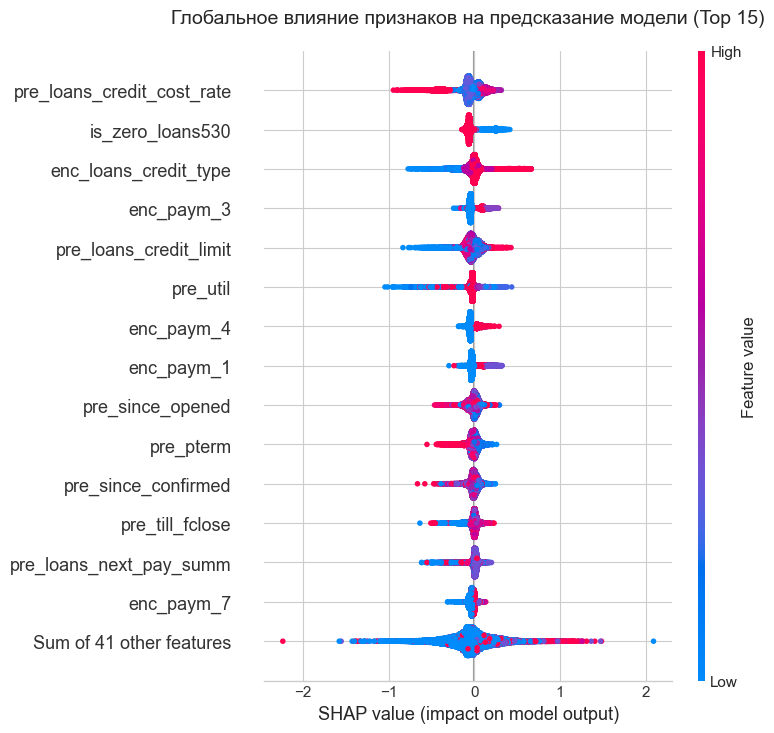

<Figure size 1000x600 with 0 Axes>

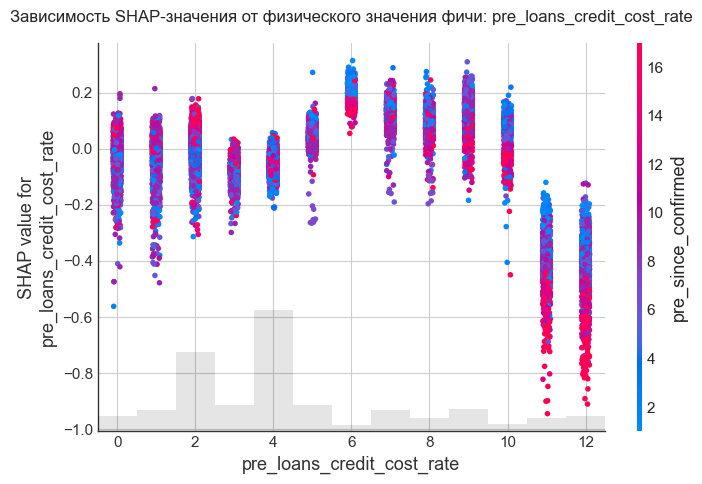

=== ТОП ПРИЗНАКОВ ПО ВЛИЯНИЮ НА МОДЕЛЬ ===


,Feature,Importance (mean |SHAP|)
10,pre_loans_credit_cost_rate,0.095689
14,is_zero_loans530,0.093097
51,enc_loans_credit_type,0.070031
27,enc_paym_3,0.063511
6,pre_loans_credit_limit,0.063162
18,pre_util,0.051155
28,enc_paym_4,0.047918
25,enc_paym_1,0.047255
0,pre_since_opened,0.044307
2,pre_pterm,0.040213


In [9]:
shap_explainer.global_interpretation()

# Local Interpretation

In [10]:
# 1. Считаем предсказания и размечаем типы прогнозов (как в прошлом ноутбуке)
preds = model_wrapper.predict(X_val_clean)
error_df = X_val.copy()
error_df['Actual'] = y_val.values
error_df['Predicted'] = preds

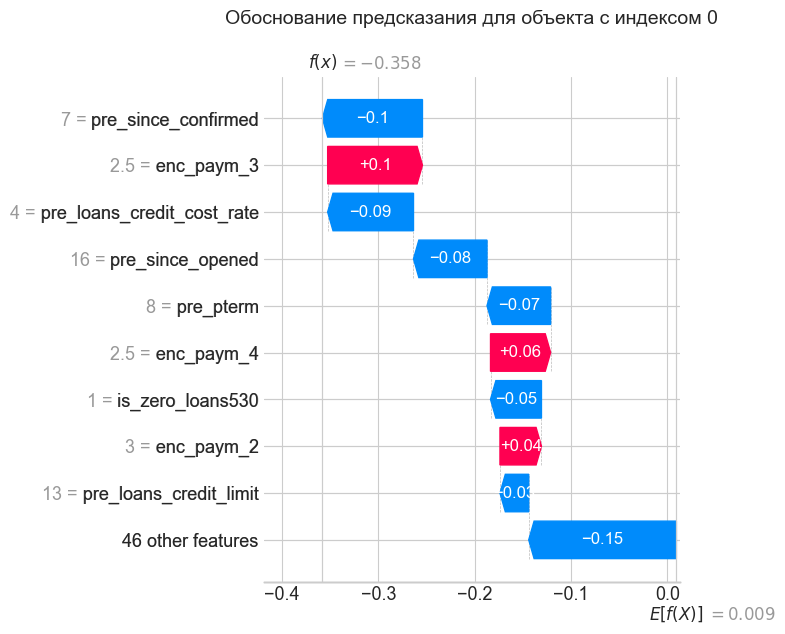

Фактическое значение таргета для этого объекта: 0
=== АНАЛИЗ SHAP ДЛЯ ЛОЖНЫХ СРАБАТЫВАНИЙ (Найдено объектов: 10310) ===


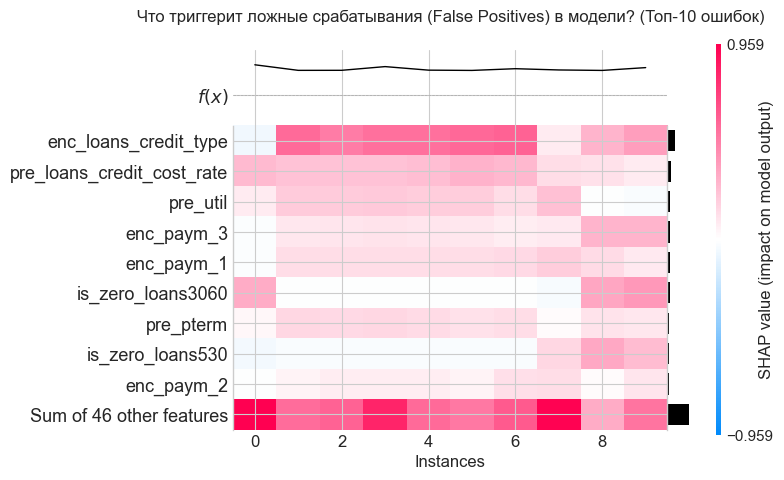

In [11]:
shap_explainer.local_interpretation(error_df=error_df)